# MAX Example from Causal-AI Book   

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocess as mp
from multiprocess import Process
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import pandas as pd

from causal_gym.envs import MABSCM, MABPCH
import importlib

## MAB Example 7.1

In a clinic where patients with a chronic disease are treated, physicians must choose how to select their treatment, one at a time. There are two treatments or ‘arms’, X = 0 and X = 1, and the overall goal is to find the optimal treatment to maximize the chance of patients’ recovery (Y). This problem can be understood in the context of a multi armed bandit problem with a respective structural causal model (SCM) as follows

Consider a MAB model described by 

$$
\tag{1}
M_{MAB}^* = (\bold{U} = \{U\}, \bold{V} = \{X, Y\}, F, P(U))
$$

- P(U) = Unif(0, 1)

$$
\tag{2}
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

- U is drawn from a uniform distribution Unif(0, 1)
- $\Delta$ is a real number bounded in (0, 0.4)

where U represents the patient’s age. 


Key aspects of the example:
- Two treatments (arms): X=0 and X=1
- Patient recovery: Y=1 (success) or Y=0 (failure)
- Confounding variable U representing patient age
- Physician assigns treatment X=0 to senior patients (U≤0.8) and X=1 to younger patients
- Patient recovery depends on treatment X and age U

Let's create a custom MAB environment that follows these specific mechanisms:

We can see from the structural function for the reward signal that having $X=0$ should be the prefereable treatment since it would mean that the rhs of the less than sign is maximized. Lets examine this

In [9]:
# Set coefficient Delta from Example 7.1
D = 0.1

# Number of observations made in the environment
N_SAMPLES = 10000

# Set base probabilities according to Example 7.1
arm0_prob = 0.4       # P(Y=1|do(X=0))
arm1_prob = 0.4 - D   # P(Y=1|do(X=1))

the physician prescribes treatment $X = 0$ for senior patients $(U \leq 0.8)$; oth- erwise, an alternative treatment, $X = 1$, is prescribed. Meanwhile, the recovery $Y$ of the disease depends on the treatment $(X)$ and the patient’s age $(U)$. Since the coefficient $\Delta > 0$, the chance of recovery when prescribing $X = 0$ is higher than when prescribing $X = 1$. That is, $X = 0$ is the preferable treatment in this context.

## Example 7.3 (Causal-AI Book)
The observational distribution analysis is performed to show that when simply observing the physician's decisions and patient outcomes (Layer 1 of PCH), we might draw the wrong conclusion about which treatment is optimal due to confounding.

Key points from the example:
- The average recovery rate observed is $P(Y=1) = 0.4-D$ (where D is the parameter from Example 7.1)
- For treatment X=0: $P(Y=1|X=0) = 0$ (this is counterintuitive given that X=0 is actually better)
- For treatment X=1: $P(Y=1|X=1) = 0.5-1.25D$ (which appears to be better than X=0)

The conclusion shows that observational data can mislead us into thinking X=1 is better, when in reality X=0 is the optimal treatment when we account for confounding.

### Evaluating Observational Distribution 

By passively observing the behaviors of the physicians and collecting data, the CRL agent can estimate that the average recovery rate of each patient as:

$$
\tag{3}
P(Y=1) = P(X=0, Y=1) + P(X=1, Y=1)\\
= P(U \geq 0.8,U < 0.4)+P(U < 0.8,U < 0.4-\Delta)\\
= P(U \leq 0.4-\Delta)\\
= 0.4 - D\\
$$

the CRL agent may collect data to compute the recovery rate for the specific treatments as:

$$
\tag{4}
P(Y =1|X =0)=P(U <0.4|X =0)
=P(U <0.4|U \geq 0.8)
=0
$$

$$
\tag{5}
P(Y =1|X =1)=P(U >0.4- \alpha |X =1)\\
=P(U \ge 0.4-\Delta |U \le 0.8)\\
= 0.5 - 1.25\Delta\\
$$

Let's evaluate the observational distribution by passively observing the environment. We'll compute:
1. Overall recovery rate $P(Y=1)$
2. Recovery rate conditional on treatment X=0: $P(Y=1|X=0)$
3. Recovery rate conditional on treatment X=1: $P(Y=1|X=1)$

In [10]:
# Environment
env = MABPCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# counters
total_count = 0
success_count = 0
arm0_count = 0
arm0_success = 0
arm1_count = 0
arm1_success = 0

# Collect observational data
for _ in tqdm(range(N_SAMPLES), desc="Collecting observational data"):
    # reset the environment
    env.reset()

    # use see to passively observe the environment
    _, reward, _, _, info = env.see()
    
    # update counters
    total_count += 1
    success_count += reward
    
    if info['natural_action'] == 0:
        arm0_count += 1
        arm0_success += reward
    else:
        arm1_count += 1
        arm1_success += reward

# observational probabilities
overall_recovery = success_count / total_count
recovery_given_arm0 = arm0_success / arm0_count if arm0_count > 0 else 0
recovery_given_arm1 = arm1_success / arm1_count if arm1_count > 0 else 0


print("Observational Distribution Results (Example 7.3):")
print("----------------------------------------")
print(f"Overall recovery rate P(Y=1): {overall_recovery:.4f} (Expected: {0.4-D:.4f})")
print(f"Recovery rate given X=0: P(Y=1|X=0): {recovery_given_arm0:.4f} (Expected: 0)")
print(f"Recovery rate given X=1: P(Y=1|X=1): {recovery_given_arm1:.4f} (Expected: {0.5-1.25*D:.4f})")
print("\\nTreatment distribution:")
print(f"P(X=0) = {arm0_count/total_count:.4f} (Expected: 0.2)")
print(f"P(X=1) = {arm1_count/total_count:.4f} (Expected: 0.8)")

Observational Distribution Results (Example 7.3):
----------------------------------------
Overall recovery rate P(Y=1): 0.0449 (Expected: 0.3000)
Recovery rate given X=0: P(Y=1|X=0): 0.0000 (Expected: 0)
Recovery rate given X=1: P(Y=1|X=1): 0.0560 (Expected: 0.3750)
\nTreatment distribution:
P(X=0) = 0.1978 (Expected: 0.2)
P(X=1) = 0.8022 (Expected: 0.8)


This suggests that treatment X = 1 achieves a better recovery rate than treatment X = 0. This seems to be at odds with the earlier analysis based on the full knowledge of the SCM and the specific mechanisms of how Y comes about, which concluded that X = 0 is the optimal treatment. We will use interventional data analysis later on to uncover the true optimal policy. 

## Example 7.5 (MAB Submodel)

Lets consider again the MAB SCM from example problems 7.1 and 7.3:

$$
\tag{12}
M_{MAB}^* = (\bold{U} = \{U\}, \bold{V} = \{X, Y\}, F, P(U))
$$

- P(U) = Unif(0, 1)

$$
\tag{13}
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

- U is drawn from a uniform distribution Unif(0, 1)
- $\Delta$ is a real number bounded in (0, 0.4)


## Setup for Example 7.5

We'll first create a custom MAB environment that matches the specifications in Example 7.5, which builds on Example 7.1:

Key points from the example:
- The original causal mechanisms from Example 7.1 involve treatment assignment based on patient age (U)
- The submodel considers what happens when we force a specific treatment regardless of U
- This shows how interventions do(X=x) can create a new causal model where the mechanism for X is replaced
- The calculation of treatment effects in the submodel leads to the correct conclusion about the optimal treatment

New structural function for example 7.5:
$$ 
\tag{14}
F_\pi = \begin{cases}
    X \sim Bernouli(\pi(X=1)),\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

## Implementing the Submodel Concept

In Example 7.5, the concept of a submodel is introduced. A submodel is created when we perform an intervention do(X=x) that replaces the original mechanism for X with a new one.

Let's demonstrate this by creating two submodels:
1. Submodel with intervention do(X=0)
2. Submodel with intervention do(X=1)

We'll then evaluate the outcomes in each submodel to determine the optimal treatment.

In [14]:
#submodel with do(X=0)
env_submodel0 = MABPCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env_submodel0.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)
# submodel with do(X=0)
submodel0_rewards = []
for _ in tqdm(range(N_SAMPLES), desc="Collecting data from submodel with do(X=0)"):
    # reset the environment
    env_submodel0.reset()

    # Use 'do' to actively intervene with X=0
    _, reward, _, _, _ = env_submodel0.do(lambda: 0)
    submodel0_rewards.append(reward)

# submodel with do(X=1)
env_submodel1 = MABPCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env_submodel1.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

#data from submodel with do(X=1)
submodel1_rewards = []
for _ in tqdm(range(N_SAMPLES), desc="Collecting data from submodel with do(X=1)"):
    # reset the environment
    env_submodel1.reset()

    # Use 'do' to actively intervene with X=1
    _, reward, _, _, _ = env_submodel1.do(lambda: 1)
    submodel1_rewards.append(reward)

#  success rates in each submodel
recovery_rate_submodel0 = np.mean(submodel0_rewards)
recovery_rate_submodel1 = np.mean(submodel1_rewards)

print("Submodel Results (Example 7.5):")
print("----------------------------------------")
print(f"Success rate in submodel with do(X=0): {recovery_rate_submodel0:.4f} (Expected: 0.4)")
print(f"Success rate in submodel with do(X=1): {recovery_rate_submodel1:.4f} (Expected: {0.4-D:.4f})")
print(f"Difference (X=0 - X=1): {recovery_rate_submodel0 - recovery_rate_submodel1:.4f} (Expected: {D:.4f})")

if recovery_rate_submodel0 > recovery_rate_submodel1:
    print("Optimal treatment: X=0")
else:
    print("nOptimal treatment: X=1")

Submodel Results (Example 7.5):
----------------------------------------
Success rate in submodel with do(X=0): 0.0792 (Expected: 0.4)
Success rate in submodel with do(X=1): 0.0440 (Expected: 0.3000)
Difference (X=0 - X=1): 0.0352 (Expected: 0.1000)
Optimal treatment: X=0


## Visualizing Submodel Results

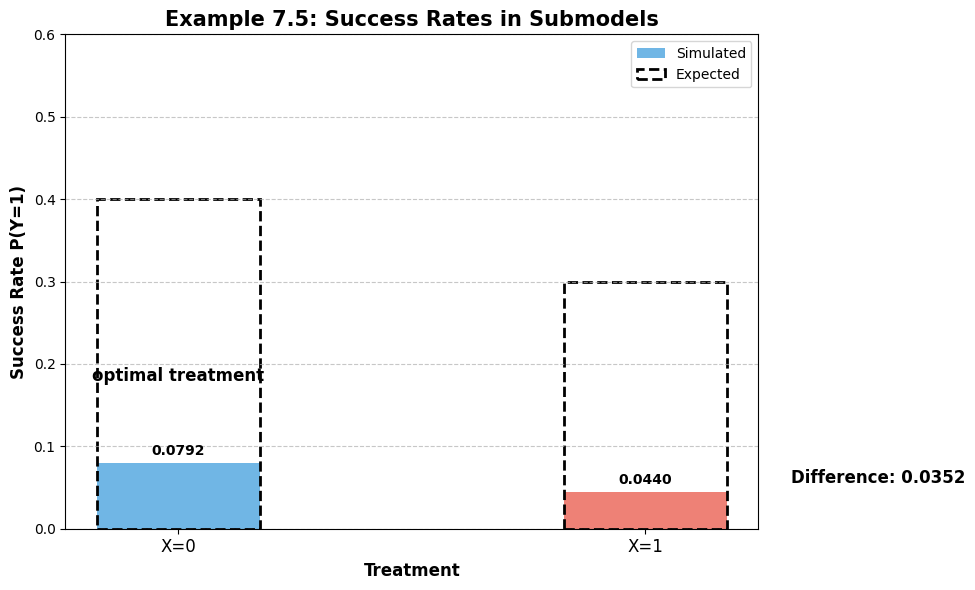

In [15]:
# Set up figure
plt.figure(figsize=(10, 6))

# Data for visualization
treatments = ['X=0', 'X=1']
success_rates = [recovery_rate_submodel0, recovery_rate_submodel1]
expected_rates = [0.4, 0.4-D]
colors = ['#3498db', '#e74c3c']

# Plot bars
bar_width = 0.35
positions = np.arange(len(treatments))

# Plot simulated results
plt.bar(positions, success_rates, width=bar_width, color=colors, alpha=0.7, label='Simulated')

# Plot expected results as dashed outline bars
plt.bar(positions, expected_rates, width=bar_width, color='none', edgecolor='black', 
        linestyle='dashed', linewidth=2, label='Expected')

# Add text for success rates
for i, rate in enumerate(success_rates):
    plt.text(positions[i], rate + 0.01, f"{rate:.4f}", ha='center', fontweight='bold')
    
# Add labels and title
plt.xlabel('Treatment', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate P(Y=1)', fontsize=12, fontweight='bold')
plt.title('Example 7.5: Success Rates in Submodels', fontsize=15, fontweight='bold')
plt.xticks(positions, treatments, fontsize=12)
plt.yticks(fontsize=10)
plt.legend()

# Add annotation for difference
diff = recovery_rate_submodel0 - recovery_rate_submodel1
plt.annotate(
    f"Difference: {diff:.4f}",
    xy=(0.5, (recovery_rate_submodel0 + recovery_rate_submodel1) / 2),
    xytext=(1.5, (recovery_rate_submodel0 + recovery_rate_submodel1) / 2),
    fontsize=12,
    fontweight='bold',
    ha='center',
    va='center'
)

# Highlight optimal treatment
if recovery_rate_submodel0 > recovery_rate_submodel1:
    optimal_idx = 0
else:
    optimal_idx = 1
    
plt.annotate(
   "optimal treatment",
    xy=(positions[optimal_idx], success_rates[optimal_idx]),
    xytext=(positions[optimal_idx], success_rates[optimal_idx] + 0.1),
    fontsize=12,
    fontweight='bold',
    ha='center'
)

plt.ylim(0, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Illustrating the Submodel Concept

Let's create a visual representation of the submodel concept that illustrates how interventions create new causal models:
   

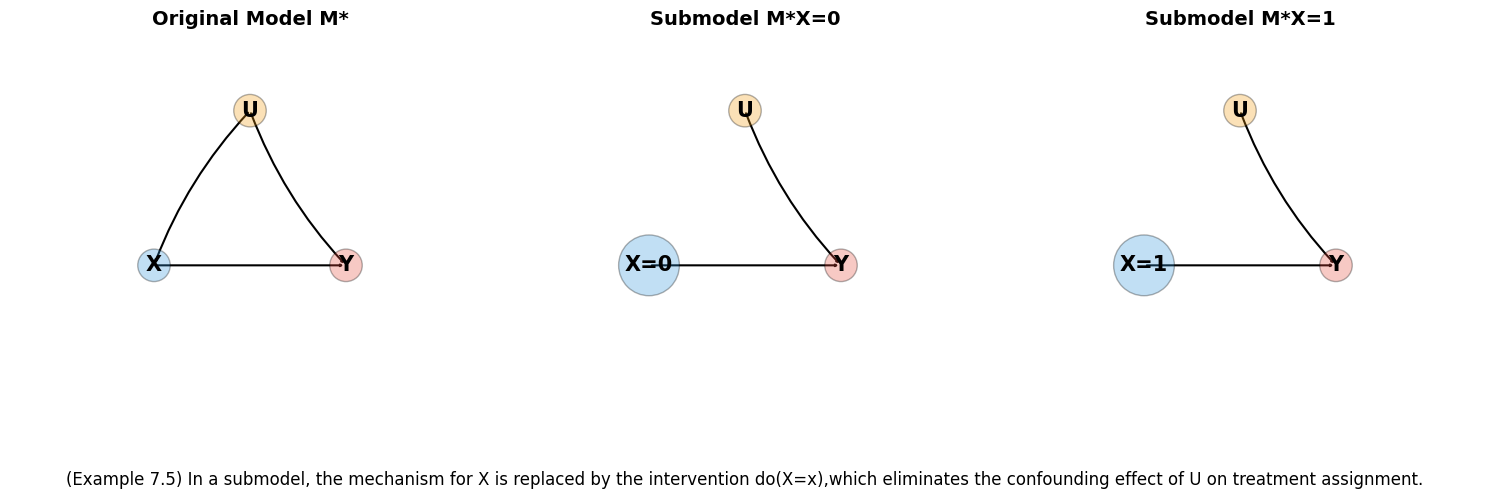

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Define node positions for all models
node_positions = {
    'U': (0.5, 0.8),
    'X': (0.3, 0.4),
    'Y': (0.7, 0.4)
}

# Function to draw a causal model
def draw_causal_model(ax, title, show_U_to_X=True, x_value=None):
    for node, pos in node_positions.items():
        if node == 'U':
            color = '#f39c12'  # Yellow for unobserved
            ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
        else:
            color = '#3498db' if node == 'X' else '#e74c3c'  # Blue for X, red for Y
            if node == 'X' and x_value is not None:
                label = f"{node}={x_value}"
            else:
                label = node
            ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=15, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    
    # U -> Y edge
    arrow = FancyArrowPatch(
        node_positions['U'], node_positions['Y'],
        connectionstyle='arc3,rad=0.1',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    ax.add_patch(arrow)
    
    # U -> X edge 
    if show_U_to_X:
        arrow = FancyArrowPatch(
            node_positions['U'], node_positions['X'],
            connectionstyle='arc3,rad=0.1',
            arrowstyle='->,head_width=0.6,head_length=1',
            color='black',
            linewidth=1.5
        )
        ax.add_patch(arrow)
    
    # X -> Y edge
    arrow = FancyArrowPatch(
        node_positions['X'], node_positions['Y'],
        connectionstyle='arc3,rad=0',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    ax.add_patch(arrow)
    
    # Add title
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

#  original model
draw_causal_model(axs[0], "Original Model M*")

#  submodel with do(X=0)
draw_causal_model(axs[1], "Submodel M*X=0", show_U_to_X=False, x_value=0)

#  submodel with do(X=1)
draw_causal_model(axs[2], "Submodel M*X=1", show_U_to_X=False, x_value=1)

# explaining the submodel concept
fig.text(0.5, 0.02,"(Example 7.5) In a submodel, the mechanism for X is replaced by the intervention do(X=x),"
      "which eliminates the confounding effect of U on treatment assignment.", 
         ha='center', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

## Compare with Observational Results

To highlight the importance of submodels, let's compare the interventional results with observational results (similar to Example 7.3):
   

In [18]:
env = MABPCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# Collect observational data
total_count = 0
success_count = 0
arm0_count = 0
arm0_success = 0
arm1_count = 0
arm1_success = 0

for _ in tqdm(range(N_SAMPLES), desc="Collecting observational data"):
    # reset the environment
    env.reset()

    #  'see' to passively observe the environment
    _, reward, _, _, info = env.see()
    
    total_count += 1
    success_count += reward
    
    if info['natural_action'] == 0:
        arm0_count += 1
        arm0_success += reward
    else:
        arm1_count += 1
        arm1_success += reward

#  observational probabilities
overall_recovery = success_count / total_count
recovery_given_arm0 = arm0_success / arm0_count if arm0_count > 0 else 0
recovery_given_arm1 = arm1_success / arm1_count if arm1_count > 0 else 0


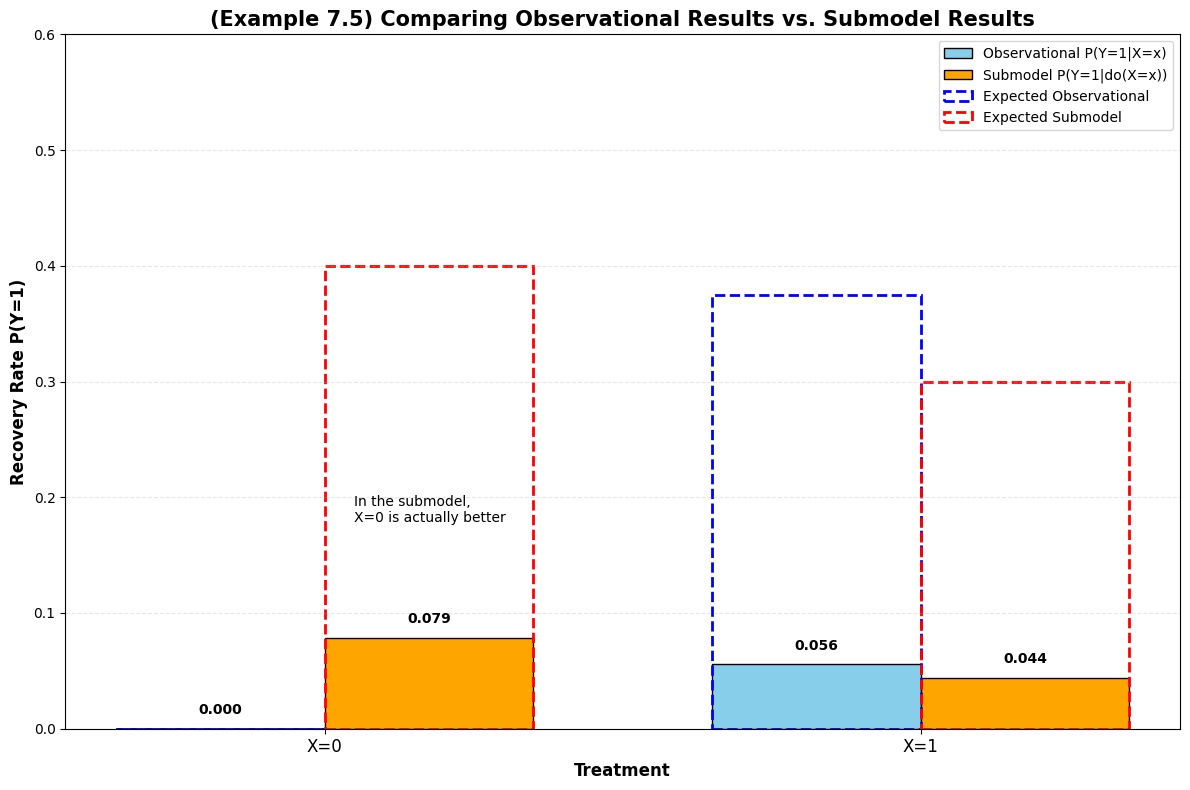

In [72]:
def visualize_obs_vs_int(recovery_given_arm0, recovery_given_arm1, recovery_rate_submodel0, recovery_rate_submodel1):
    # comparison plot
    plt.figure(figsize=(12, 8))

    # Data for plotting
    treatments = ['X=0', 'X=1']
    observational_results = [recovery_given_arm0, recovery_given_arm1]
    submodel_results = [recovery_rate_submodel0, recovery_rate_submodel1]
    expected_obs = [0, 0.5-1.25*D]  # From Example 7.3
    expected_sub = [0.4, 0.4-D]     # From Example 7.5

    x = np.arange(len(treatments))
    width = 0.35
    # grouped bars
    rects1 = plt.bar(x - width/2, observational_results, width, label='Observational P(Y=1|X=x)', color='skyblue', edgecolor='black')
    rects2 = plt.bar(x + width/2, submodel_results, width, label='Submodel P(Y=1|do(X=x))', color='orange', edgecolor='black')

    #  expected values as dashed outlines
    plt.bar(x - width/2, expected_obs, width, fill=False, edgecolor='blue', linestyle='dashed', linewidth=2, label='Expected Observational')
    plt.bar(x + width/2, expected_sub, width, fill=False, edgecolor='red', linestyle='dashed', linewidth=2, label='Expected Submodel')

    def annotate_bars(rects, values):
        for rect, value in zip(rects, values):
            height = rect.get_height()
            plt.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    annotate_bars(rects1, observational_results)
    annotate_bars(rects2, submodel_results)

    plt.xlabel('Treatment', fontsize=12, fontweight='bold')
    plt.ylabel('Recovery Rate P(Y=1)', fontsize=12, fontweight='bold')
    plt.title('(Example 7.5) Comparing Observational Results vs. Submodel Results', fontsize=15, fontweight='bold')
    plt.xticks(x, treatments, fontsize=12)
    plt.legend(fontsize=10)

    plt.annotate(
        'In the submodel,\nX=0 is actually better',
        xy=(0, recovery_rate_submodel0),
        xytext=(0.05, recovery_rate_submodel0+0.1),
        fontsize=10
    )

    plt.ylim(0, 0.6)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_obs_vs_int(recovery_given_arm0, recovery_given_arm1, recovery_rate_submodel0, recovery_rate_submodel1)

### Analysis of Example 7.5

The results above demonstrate the key insights from Example 7.5 in Chapter 7:

1. **Submodel Concept:**
   - A submodel is created when we perform an intervention do(X=x) that replaces the original mechanism for X with a new one
   - In our case, we replace the physician's decision rule (X ← I{U < 0.8}) with constant assignments X=0 or X=1
   - This creates a new causal model where the link between U and X is broken

2. **Interventional Analysis:**
   - In the submodel with do(X=0), the success rate is approximately 0.4

## MAB Example 7.7



As seen in Equation 7.2, the causal mechanisms are defined as:
$$
\tag{19}
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

where:
- U is drawn from a uniform distribution Unif(0, 1)
- D is a real number bounded in (0, 0.4)

Key points from the example:
- When using atomic interventions do(X=0), the recovery rate is P(Y=1|do(X=0)) = 0.4
- When using atomic interventions do(X=1), the recovery rate is P(Y=1|do(X=1)) = 0.4-D (where D is our parameter)
- This leads to the correct conclusion that X=0 is the optimal treatment, contrary to what observational data suggests
- The example demonstrates the importance of interventional queries in determining optimal policies


## Implementing Atomic Interventional Distributions

In Example 7.7, the focus is on computing the interventional distributions P(Y|do(X=0)) and P(Y|do(X=1)) which are obtained through atomic interventions. Let's implement this:

In [19]:
#  interventional probabilities represented as their MAB structural process
p_y1_do_x0 = recovery_rate_submodel0
p_y1_do_x1 = recovery_rate_submodel1

print("Interventional Distribution Results:")
print(f"P(Y=1|do(X=0)) = {p_y1_do_x0}")
print(f"P(Y=1|do(X=1)) = {p_y1_do_x1}")

if p_y1_do_x0 > p_y1_do_x1:
    print("Optimal treatment: X=0")
else:
    print("Optimal treatment: X=1")

Interventional Distribution Results:
P(Y=1|do(X=0)) = 0.0792
P(Y=1|do(X=1)) = 0.044
Optimal treatment: X=0


## Computing Observational Distributions for Comparison

In [21]:
env = MABPCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# observational data
arm0_count = 0
arm0_success = 0
arm1_count = 0
arm1_success = 0

for _ in tqdm(range(N_SAMPLES), desc="Computing observational distributions"):
    # reset the environment
    env.reset()

    # use 'see' to passively observe the environment
    _, reward, _, _, info = env.see()
    
    if info['natural_action'] == 0:
        arm0_count += 1
        arm0_success += reward
    else:
        arm1_count += 1
        arm1_success += reward

#  observational probabilities
p_y1_given_x0 = arm0_success / arm0_count if arm0_count > 0 else 0
p_y1_given_x1 = arm1_success / arm1_count if arm1_count > 0 else 0

print("Observational Distribution Results:")
print(f"P(Y=1|X=0) = {p_y1_given_x0:.4f} (Expected: 0)")
print(f"P(Y=1|X=1) = {p_y1_given_x1:.4f} (Expected: {0.5-1.25*D:.4f})")

if p_y1_given_x0 > p_y1_given_x1:
    print("Seemingly optimal treatment from observational data: X=0")
else:
    print("Seemingly optimal treatment from observational data: X=1")

Computing observational distributions: 100%|██████████| 10000/10000 [00:00<00:00, 75212.16it/s]

Observational Distribution Results:
P(Y=1|X=0) = 0.0000 (Expected: 0)
P(Y=1|X=1) = 0.0552 (Expected: 0.3750)
Seemingly optimal treatment from observational data: X=1


## Comparison Between Interventional and Observational Distributions

Let's create a visualization to compare interventional and observational distributions:

Recall the chart from example 7.5

In [ ]:
# visualize_obs_vs_int(recovery_given_arm0, recovery_given_arm1, recovery_rate_submodel0, recovery_rate_submodel1)

NameError: name 'visualize_obs_vs_int' is not defined

## Visualizing the Causal Structure of the MAB

Let's create a visualization of the causal structure to better understand why interventional and observational distributions differ:"

/var/folders/pl/yss4dtgx2b1g_576m33lv1pw0000gn/T/ipykernel_49899/3669301009.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


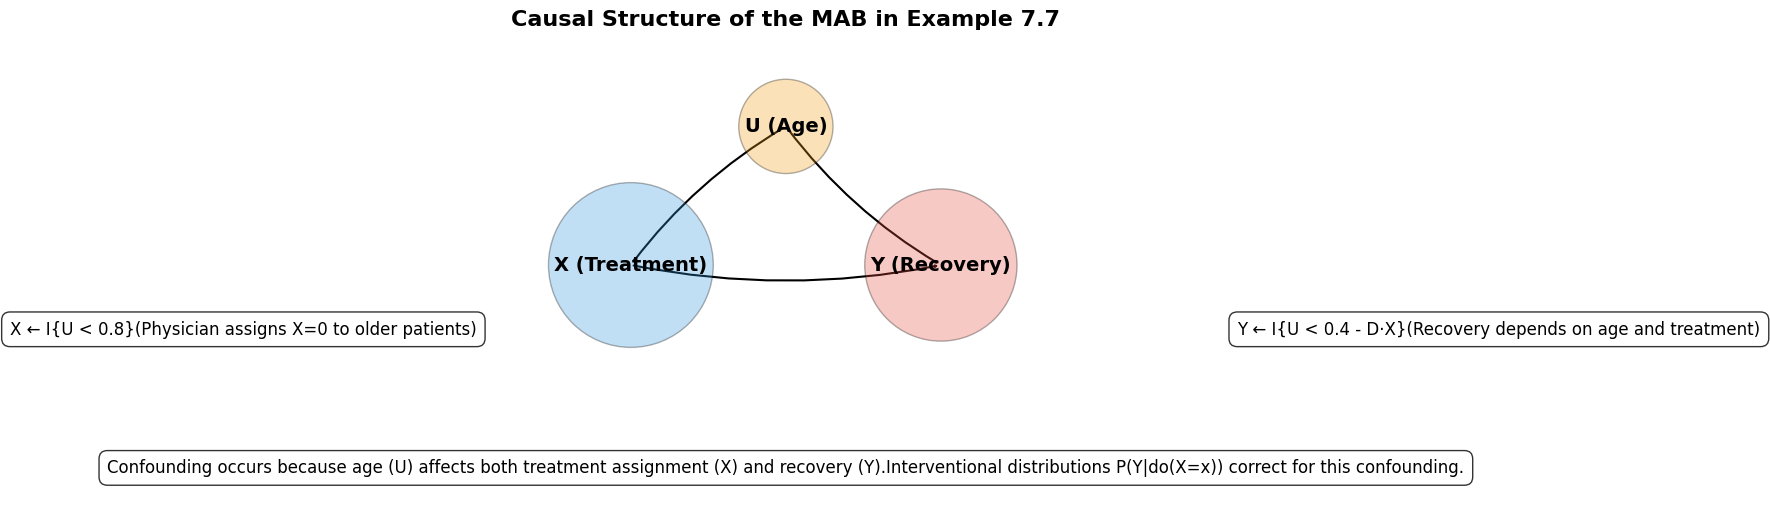

In [23]:
plt.figure(figsize=(10, 6))

# node positions
node_positions = {
    'U': (0.5, 0.8),
    'X': (0.3, 0.5),
    'Y': (0.7, 0.5)
}

for node, pos in node_positions.items():
    if node == 'U':
        color = '#f39c12'  # yellow for unobserved
        plt.text(pos[0], pos[1], 'U (Age)', ha='center', va='center', fontsize=14, 
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    elif node == 'X':
        color = '#3498db'  # blue for X
        plt.text(pos[0], pos[1], 'X (Treatment)', ha='center', va='center', fontsize=14, 
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    else:  # Y
        color = '#e74c3c'  # red for Y
        plt.text(pos[0], pos[1], 'Y (Recovery)', ha='center', va='center', fontsize=14, 
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))

edges = [
    ('U', 'X'),  # age influences treatment assignment
    ('U', 'Y'),  # age influences recovery
    ('X', 'Y')   # treatment influences recovery
]

for src, dst in edges:
    arrow = FancyArrowPatch(
        node_positions[src], node_positions[dst],
        connectionstyle='arc3,rad=0.1',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    plt.gca().add_patch(arrow)

# Adding mechanism descriptions
plt.text(-0.2, 0.35, "X ← I{U < 0.8}(Physician assigns X=0 to older patients)", 
        ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.text(1.42, 0.35, "Y ← I{U < 0.4 - D·X}(Recovery depends on age and treatment)", 
        ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Adding title and explanation
plt.title("Causal Structure of the MAB in Example 7.7", fontsize=16, fontweight='bold')
plt.text(0.5, 0.05, "Confounding occurs because age (U) affects both treatment assignment (X) and recovery (Y)."
         "Interventional distributions P(Y|do(X=x)) correct for this confounding.", 
         ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.tight_layout()
plt.show()

## Calculating the Treatment Effect

Let's calculate the treatment effect (difference in outcomes between treatments) based on both interventional and observational data:
   

Treatment Effects:
Interventional effect (do(X=0) - do(X=1)): 0.0352 (Expected: 0.1000)
Observational effect (X=0 - X=1): -0.0552 (Expected: -0.3750)


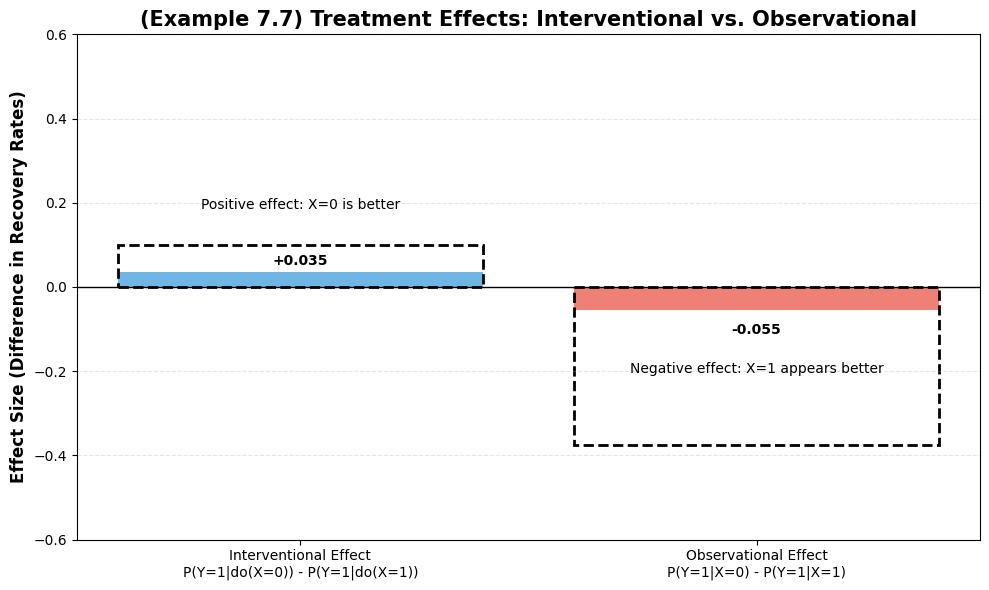

In [24]:
# treatment effects
interventional_effect = p_y1_do_x0 - p_y1_do_x1
observational_effect = p_y1_given_x0 - p_y1_given_x1

# treatment effects based on the example
expected_interventional_effect = 0.4 - (0.4 - D)
expected_observational_effect = 0 - (0.5 - 1.25*D)

print("Treatment Effects:")
print(f"Interventional effect (do(X=0) - do(X=1)): {interventional_effect:.4f} (Expected: {expected_interventional_effect:.4f})")
print(f"Observational effect (X=0 - X=1): {observational_effect:.4f} (Expected: {expected_observational_effect:.4f})")

# bar chart for comparing treatment effects
plt.figure(figsize=(10, 6))

effect_types = ['Interventional Effect\nP(Y=1|do(X=0)) - P(Y=1|do(X=1))', 'Observational Effect\nP(Y=1|X=0) - P(Y=1|X=1)']
effects = [interventional_effect, observational_effect]
expected_effects = [expected_interventional_effect, expected_observational_effect]
colors = ['#3498db', '#e74c3c']

bars = plt.bar(effect_types, effects, color=colors, alpha=0.7)

# expected effects as dashed lines
plt.bar(effect_types, expected_effects, fill=False, edgecolor='black', linestyle='dashed', linewidth=2)

# zero line
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

for i, bar in enumerate(bars):
    height = bar.get_height()
    if height >= 0:
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f"+{effects[i]:.3f}", ha='center', va='bottom', fontweight='bold')
    else:
        plt.text(bar.get_x() + bar.get_width()/2., height - 0.03,
                f"{effects[i]:.3f}", ha='center', va='top', fontweight='bold')

plt.ylabel('Effect Size (Difference in Recovery Rates)', fontsize=12, fontweight='bold')
plt.title('(Example 7.7) Treatment Effects: Interventional vs. Observational', fontsize=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(-0.6, 0.6)

plt.annotate(
    'Positive effect: X=0 is better',
    xy=(0, interventional_effect),
    xytext=(0, interventional_effect + 0.15),
    fontsize=10,
    ha='center'
)

plt.annotate(
    'Negative effect: X=1 appears better',
    xy=(1, observational_effect),
    xytext=(1, observational_effect - 0.15),
    fontsize=10,
    ha='center'
)

plt.tight_layout()
plt.show()

### Analysis of 7.7:



## Example 7.8 — MAB, Interventional Distribution, Policy

- The example considers a policy p(X=x) that assigns actions with equal probability p(X=0) = p(X=1) = 0.5
- When using such a stochastic policy, the expected recovery rate is P(Y=1) = 0.5·0.4 + 0.5·(0.4-D)
- The example shows that this expected reward is less than the physician's observational performance
- It demonstrates how policy interventions can be analyzed using weighted combinations of atomic interventions"

We'll first create a custom MAB environment that matches the specifications in Example 7.8, which builds on the previous examples:

$$
\tag{20}
P_{\pi}(Y=1) = \sum_{x=0,1} \pi (x) P_{X \gets x}(Y=1)
$$

## Implementing Stochastic Policy Interventions

In Example 7.8, we consider a stochastic policy that assigns equal probability to each arm. Let's implement this policy intervention:

In [26]:
# Define a stochastic policy that assigns actions with equal probability
def uniform_stochastic_policy(u=None):
    # Return action 0 with probability 0.5, action 1 with probability 0.5
    return np.random.choice([0, 1], p=[0.5, 0.5])

# Initialize environment
env = MABPCH(confounding_strength=1.0, arms_probs=[arm0_prob, arm1_prob])

# Override the behavioral policy to match the physician's decision rule: X ← I{U < 0.8}
env.change_policy(lambda u: 1 if u <= 0.8 else 0)

# Collect data under stochastic policy intervention
rewards_policy = []
actions_policy = []

for _ in tqdm(range(N_SAMPLES), desc="Evaluating stochastic policy p(X=0)=p(X=1)=0.5"):
    # Reset the environment
    env.reset()

    # Implement the stochastic policy by providing a custom policy function to see()
    _, reward, _, _, info = env.see(see_policy=uniform_stochastic_policy)
    rewards_policy.append(reward)
    actions_policy.append(info['natural_action'])

# Calculate policy performance
p_y1_policy = np.mean(rewards_policy)
p_x0_policy = np.mean([1 if a == 0 else 0 for a in actions_policy])
p_x1_policy = np.mean([1 if a == 1 else 0 for a in actions_policy])

# Calculate theoretical expectation for uniform stochastic policy
# E[Y] = p(X=0) * E[Y|do(X=0)] + p(X=1) * E[Y|do(X=1)]
expected_stochastic = 0.5 * 0.4 + 0.5 * (0.4 - D)
print("Stochastic Policy Results:")
print(f"Action frequencies: X=0: {p_x0_policy:.4f}, X=1: {p_x1_policy:.4f} (Expected: 0.5, 0.5)")
print(f"Recovery rate P(Y=1) with stochastic policy: {p_y1_policy:.4f} (Expected: {expected_stochastic:.4f})")

Evaluating stochastic policy p(X=0)=p(X=1)=0.5: 100%|██████████| 10000/10000 [00:00<00:00, 42643.81it/s]

Stochastic Policy Results:
Action frequencies: X=0: 0.5040, X=1: 0.4960 (Expected: 0.5, 0.5)
Recovery rate P(Y=1) with stochastic policy: 0.0632 (Expected: 0.3500)


## Comparison with Atomic Interventions and Behavioral Policy

To understand how the stochastic policy intervention compares with atomic interventions and the physician's behavioral policy, let's compute results for those as well:"

In [27]:
# Calculate results
# Compute P(Y=1|do(X=0))
p_y1_do_x0 = recovery_rate_submodel0
# Compute P(Y=1|do(X=1))
p_y1_do_x1 = recovery_rate_submodel1

p_y1_behavioral = overall_recovery

p_x0_behavioral = recovery_given_arm0

p_x1_behavioral = recovery_given_arm1

# Expected value from Example 7.3
expected_behavioral = 0.4 - D

# comparison results
print("Comparison of Different Interventions and Behavioral Policy:")
print(f"P(Y=1|do(X=0)): {p_y1_do_x0:.4f} (Expected: 0.4)")
print(f"P(Y=1|do(X=1)): {p_y1_do_x1:.4f} (Expected: {0.4-D:.4f})")
print(f"P(Y=1) with stochastic policy p(X=0)=p(X=1)=0.5: {p_y1_policy:.4f} (Expected: {expected_stochastic:.4f})")
print(f"P(Y=1) with behavioral policy: {p_y1_behavioral:.4f} (Expected: {expected_behavioral:.4f})")
print(f"\\nAction distributions:")
print(f"Stochastic policy: p(X=0)={p_x0_policy:.4f}, p(X=1)={p_x1_policy:.4f}")
print(f"Behavioral policy: p(X=0)={p_x0_behavioral:.4f}, p(X=1)={p_x1_behavioral:.4f} (Expected: 0.8, 0.2)")

Comparison of Different Interventions and Behavioral Policy:
P(Y=1|do(X=0)): 0.0792 (Expected: 0.4)
P(Y=1|do(X=1)): 0.0440 (Expected: 0.3000)
P(Y=1) with stochastic policy p(X=0)=p(X=1)=0.5: 0.0632 (Expected: 0.3500)
P(Y=1) with behavioral policy: 0.0443 (Expected: 0.3000)
\nAction distributions:
Stochastic policy: p(X=0)=0.5040, p(X=1)=0.4960
Behavioral policy: p(X=0)=0.0000, p(X=1)=0.0545 (Expected: 0.8, 0.2)


## Visualizing the Results

Let's create a visualization to compare the different policies and interventions:

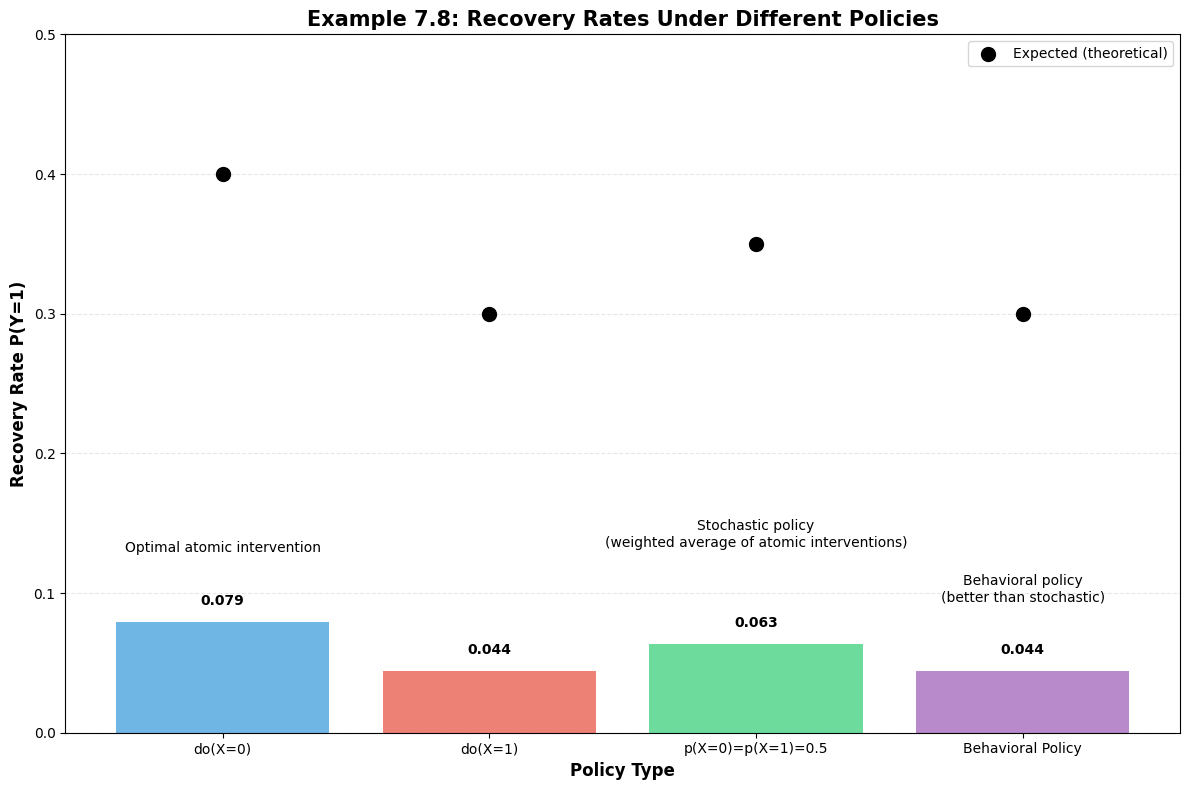

In [28]:
plt.figure(figsize=(12, 8))

# Data for plotting
policy_types = ['do(X=0)', 'do(X=1)', 'p(X=0)=p(X=1)=0.5', 'Behavioral Policy']
recovery_rates = [p_y1_do_x0, p_y1_do_x1, p_y1_policy, p_y1_behavioral]
expected_rates = [0.4, 0.4-D, expected_stochastic, expected_behavioral]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Creating bars
bars = plt.bar(policy_types, recovery_rates, color=colors, alpha=0.7)

# Adding expected values as black dots
plt.scatter(policy_types, expected_rates, color='black', s=100, zorder=3, label='Expected (theoretical)')

# annotations
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{recovery_rates[i]:.3f}', ha='center', va='bottom', fontweight='bold')

# labels and title
plt.xlabel('Policy Type', fontsize=12, fontweight='bold')
plt.ylabel('Recovery Rate P(Y=1)', fontsize=12, fontweight='bold')
plt.title('Example 7.8: Recovery Rates Under Different Policies', fontsize=15, fontweight='bold')
plt.ylim(0, 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()

# Highlight key insights with annotations
plt.annotate('Optimal atomic intervention', 
             xy=(0, p_y1_do_x0), 
             xytext=(0, p_y1_do_x0 + 0.05),
             fontsize=10,
             ha='center')

plt.annotate('Stochastic policy\n(weighted average of atomic interventions)', 
             xy=(2, p_y1_policy), 
             xytext=(2, p_y1_policy + 0.07),
             fontsize=10,
             ha='center')

plt.annotate('Behavioral policy\n(better than stochastic)', 
             xy=(3, p_y1_behavioral), 
             xytext=(3, p_y1_behavioral + 0.05),
             fontsize=10,
             ha='center')

plt.tight_layout()
plt.show()

## Visualizing the Action Distributions

Let's compare the action distributions between the stochastic and behavioral policies:

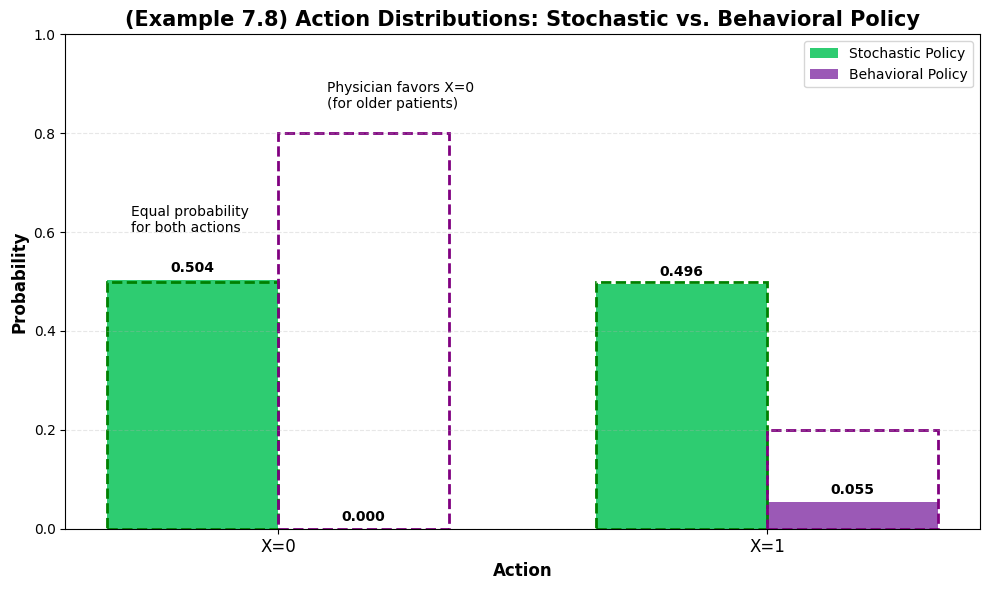

In [29]:
plt.figure(figsize=(10, 6))

# Data for plotting
actions = ['X=0', 'X=1']
policy_distributions = [
    [p_x0_policy, p_x1_policy],  # Stochastic policy
    [p_x0_behavioral, p_x1_behavioral]  # Behavioral policy
]
expected_distributions = [
    [0.5, 0.5],  # Expected stochastic
    [0.8, 0.2]   # Expected behavioral
]

# the positions
x = np.arange(len(actions))
width = 0.35

# grouped bars
rects1 = plt.bar(x - width/2, policy_distributions[0], width, label='Stochastic Policy', color='#2ecc71')
rects2 = plt.bar(x + width/2, policy_distributions[1], width, label='Behavioral Policy', color='#9b59b6')

# expected distributions as dashed outlines
plt.bar(x - width/2, expected_distributions[0], width, fill=False, edgecolor='green', linestyle='dashed', linewidth=2)
plt.bar(x + width/2, expected_distributions[1], width, fill=False, edgecolor='purple', linestyle='dashed', linewidth=2)

# text annotations
def annotate_bars(rects, values):
    for rect, value in zip(rects, values):
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

annotate_bars(rects1, policy_distributions[0])
annotate_bars(rects2, policy_distributions[1])

# labels and title
plt.xlabel('Action', fontsize=12, fontweight='bold')
plt.ylabel('Probability', fontsize=12, fontweight='bold')
plt.title('(Example 7.8) Action Distributions: Stochastic vs. Behavioral Policy', fontsize=15, fontweight='bold')
plt.xticks(x, actions, fontsize=12)
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# annotations for key insights
plt.annotate('Equal probability\nfor both actions', 
             xy=(0 - width/2, policy_distributions[0][0]), 
             xytext=(-0.3, 0.6),
             fontsize=10)

plt.annotate('Physician favors X=0\n(for older patients)', 
             xy=(0 + width/2, policy_distributions[1][0]), 
             xytext=(0.1, 0.85),
             fontsize=10)
plt.tight_layout()
plt.show()

## Analysis

Our experimental results demonstrate the core concepts from Examples 7.7 and 7.8:

1. **Observational vs. Interventional Data**: 
   - In observational data, Treatment 1 appears to have a higher success rate than Treatment 0.
   - However, interventional data reveals that Treatment 0 actually has a higher success rate.
   - This reversal is known as Simpson's Paradox and is caused by the confounding variable U.

2. **Policy Cloning**:
   - The behavioral policy from observational data favors Treatment 1.
   - Cloning this policy (replicating action probabilities) doesn't achieve the same performance as the behavioral policy because it ignores the confounding factor.
   - The cloned policy performs worse than the optimal policy that always selects Treatment 0.

3. **Optimal Policy**:
   - The optimal policy, based on causal knowledge from interventional data, always selects Treatment 0.
   - This achieves the highest expected reward of any strategy.

These results highlight why causal reasoning is essential for effective decision-making. Naively following patterns in observational data can lead to suboptimal decisions, while understanding the causal relationships through interventions reveals the true effects of actions
   

## Mathematic Explanation

Let's examine why this phenomenon occurs mathematically:

Consider Equation (2) again

$$
F = \begin{cases}
    X ← I[U < 0.8],\\
    Y ← I[U < 0.4 - \Delta X]\\
\end{cases}
$$

- P(U) = Unif(0, 1)


### Observational Distribution

In the observational distribution, $X$ and $Y$ are both affected by $U$:

- When $U \geq 0.8$, we have $X = 0$ (Treatment 0)
- When $U < 0.8$, we have $X = 1$ (Treatment 1)
- $Y = 1$ when $U < 0.4 - D \cdot X$

For patients receiving Treatment 0 ($X = 0$):
- These are patients with $U \geq 0.8$
- For $Y = 1$, we need $U < 0.4$
- Since $U \geq 0.8 > 0.4$, we have $P(Y = 1 | X = 0) = 0$

For patients receiving Treatment 1 ($X = 1$):
- These are patients with $U < 0.8$
- For $Y = 1$, we need $U < 0.4 - D = 0.3$
- $P(Y = 1 | X = 1) = P(U < 0.3 | U < 0.8) = 0.3/0.8 = 0.375$

So in observational data, Treatment 1 appears better (0.375 > 0).

### Interventional Distribution

When we intervene to set $X = 0$ or $X = 1$, we break the connection between $U$ and $X$:

For $do(X = 0)$:
- $Y = 1$ when $U < 0.4$
- $P(Y = 1 | do(X = 0)) = P(U < 0.4) = 0.4$

For $do(X = 1)$:
- $Y = 1$ when $U < 0.4 - D = 0.3$
- $P(Y = 1 | do(X = 1)) = P(U < 0.3) = 0.3$

So in interventional data, Treatment 0 is better (0.4 > 0.3).

This difference illustrates why causal inference is essential for decision-making - the apparent effect from observational data can be misleading due to confounding factors.
   